# Tesla EA Deliveries and Production Analysis (2015–2025)

## Project Objective

Tesla has experienced significant growth in vehicle production and deliveries over the past decade. Understanding the factors that influence vehicle deliveries can help improve demand forecasting and business planning.

In this project, we will analyze Tesla's delivery and production data from 2015 to 2025 and build machine learning models to predict estimated deliveries.

### Workflow

1. Data Understanding
2. Data Quality Assessment
3. Exploratory Data Analysis
4. Feature Engineering
5. Regression Modeling
6. Hyperparameter Tuning
7. Time Series Forecasting
8. Model Evaluation
9. Conclusion

## Importing Required Libraries

The following libraries will be used for data analysis, visualization, machine learning, and model evaluation.

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

## Loading the Dataset

The dataset contains Tesla production and delivery information across different regions and vehicle models.

Let's load the dataset and examine its structure.

In [16]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Rows : 2640
Columns : 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


### Dataset Features

The dataset contains information related to:

- Production Units
- Estimated Deliveries
- Vehicle Models
- Regions
- Battery Capacity
- Average Vehicle Price
- Driving Range
- Charging Infrastructure

These features can help explain variations in vehicle deliveries.

# Data Quality Assessment

A clean dataset is essential for building reliable machine learning models.

In this section, we check for:

- Missing values
- Duplicate records
- Data consistency

In [19]:
print("Missing Values\n")
print(df.isnull().sum())

Missing Values

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [20]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Observation

No missing values or duplicate records were found in the dataset.

The dataset is already well-structured and requires minimal cleaning.

#Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand trends, distributions, and relationships within the data.

The objective is to identify patterns that may influence Tesla's vehicle deliveries.

### Distribution of Estimated Deliveries

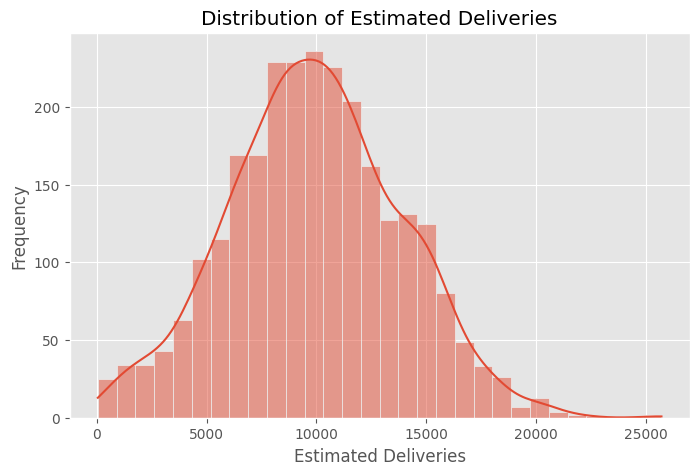

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of estimated deliveries appears approximately bell-shaped with a slight right skew.

Most delivery records fall between 7,000 and 13,000 units, while a smaller number of observations exceed 18,000 units.

This suggests that Tesla's delivery performance remains relatively consistent across most records, with occasional periods of exceptionally high deliveries.

### Average Deliveries Across Regions

Tesla operates in multiple regions worldwide.

Analyzing average deliveries by region helps identify markets that contribute most significantly to vehicle sales and may reveal regional demand differences.

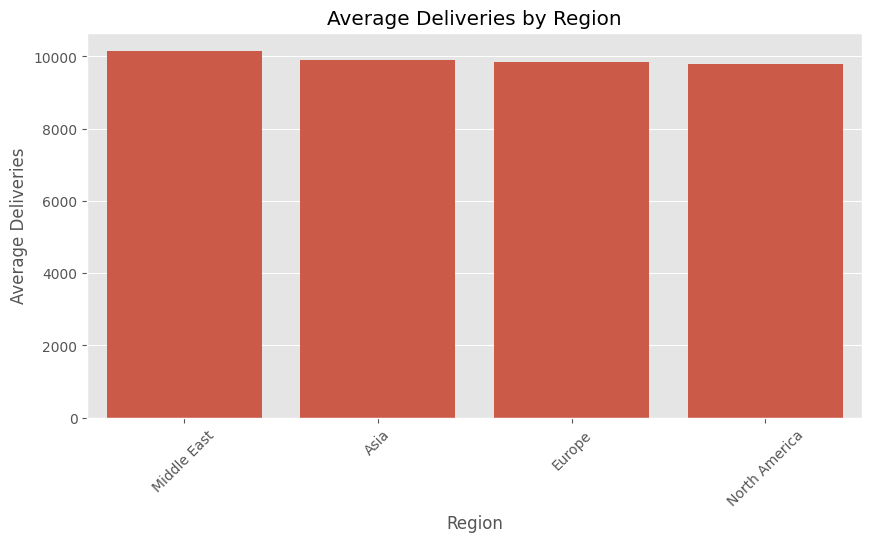

In [23]:
region_delivery = (
    df.groupby("Region")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=region_delivery.index,
    y=region_delivery.values
)

plt.xticks(rotation=45)

plt.title("Average Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Deliveries")

plt.show()

### Observation

The average deliveries across regions are relatively similar, ranging between approximately 9,800 and 10,100 vehicles.

The Middle East region shows the highest average deliveries, while North America records slightly lower average deliveries in this dataset.

Overall, regional differences appear to have only a minor impact on delivery volumes.

### Average Deliveries by Vehicle Model

Different Tesla models contribute differently to overall deliveries.

This analysis compares the average delivery volume of each vehicle model.

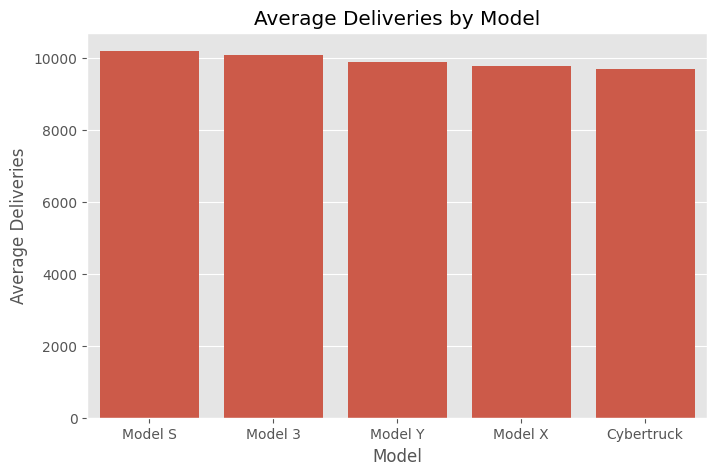

In [24]:
model_delivery = (
    df.groupby("Model")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=model_delivery.index,
    y=model_delivery.values
)

plt.title("Average Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Average Deliveries")

plt.show()

### Observation

Model S and Model 3 show the highest average deliveries among all vehicle models.

Cybertruck records the lowest average deliveries, although the differences between models are relatively small.

This suggests that vehicle model alone may not be a dominant factor affecting delivery volume.

### Relationship Between Production and Deliveries

Vehicle deliveries are expected to depend heavily on production capacity.

This visualization helps evaluate the relationship between production units and estimated deliveries.

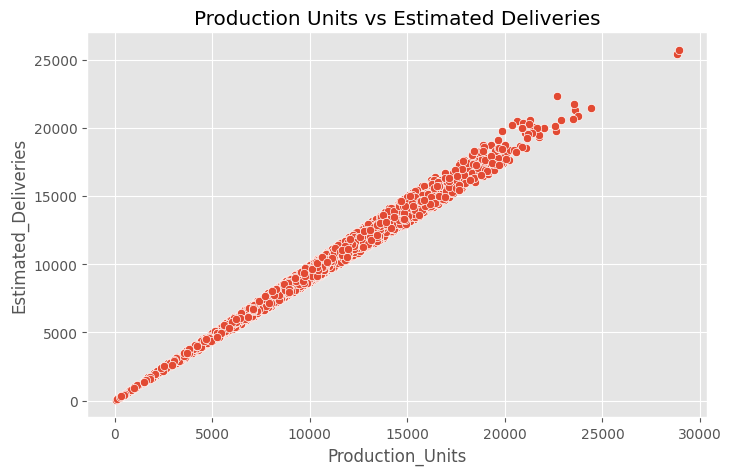

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

### Observation

A very strong positive relationship exists between Production Units and Estimated Deliveries.

The points follow an almost linear pattern, indicating that production volume is one of the strongest factors influencing vehicle deliveries.

This feature is expected to contribute significantly to prediction performance during model training.

### Correlation Matrix

The correlation matrix helps identify numerical features that are strongly associated with estimated deliveries.

Highly correlated variables often provide valuable predictive information during model training.

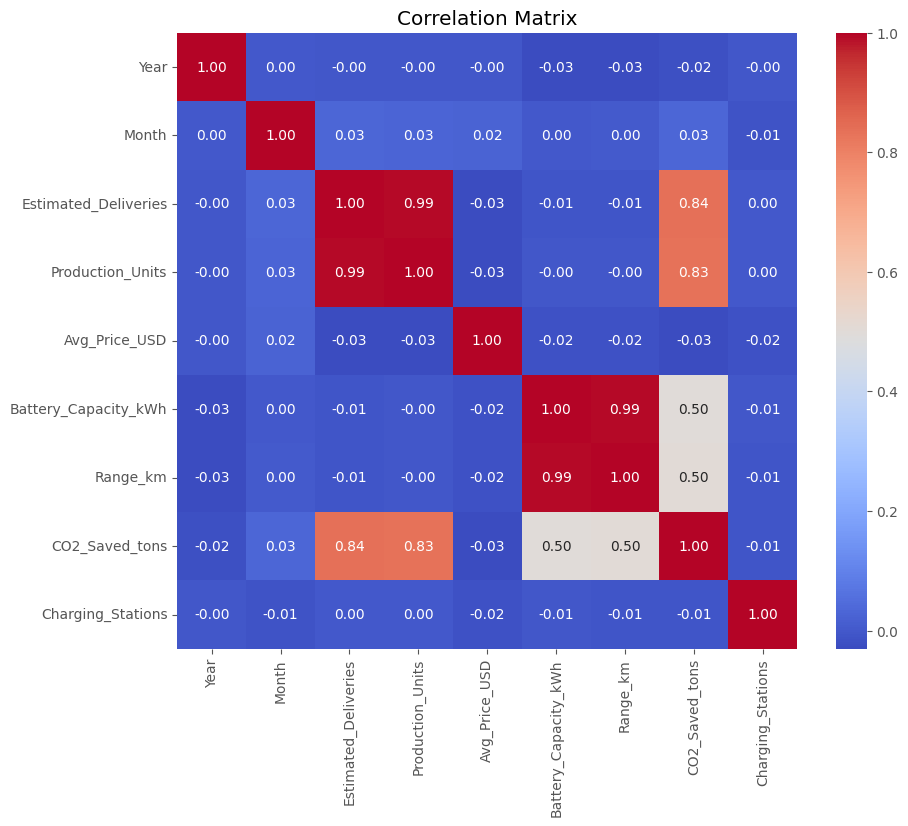

In [26]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

Several important relationships can be observed from the correlation matrix:

- Estimated Deliveries and Production Units show an extremely strong positive correlation (0.99).
- CO2 Saved shows a strong positive relationship with both Deliveries and Production Units.
- Battery Capacity and Range are highly correlated (0.99), indicating that larger batteries generally provide greater driving range.
- Year and Month have little correlation with delivery volumes.

Based on these results, Production Units appears to be the most influential predictor for delivery forecasting.

# Feature Engineering

Machine learning models require numerical input features.

The dataset contains categorical variables such as Region, Model, and Source Type, which must be converted into numerical values before training the models.

Label Encoding is used to transform these categorical features into machine-readable format.

In [27]:
data = df.copy()

categorical_features = [
    "Region",
    "Model",
    "Source_Type"
]

encoders = {}

for feature in categorical_features:
    encoder = LabelEncoder()

    data[feature] = encoder.fit_transform(
        data[feature]
    )

    encoders[feature] = encoder

data.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


### Observation

All categorical features have been successfully converted into numerical values.

The dataset is now ready for machine learning model development.

## Defining Features and Target Variable

The objective of this project is to predict vehicle deliveries.

Therefore:

- Estimated Deliveries → Target Variable
- Remaining Features → Input Variables

In [29]:
X = data.drop(
    columns=["Estimated_Deliveries"]
)

y = data["Estimated_Deliveries"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2640, 11)
Target Shape: (2640,)


## Splitting the Dataset

To evaluate model performance fairly, the dataset is divided into training and testing sets.

- 80% Training Data
- 20% Testing Data

The model learns from the training data and is evaluated using unseen test data.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 2112
Testing Samples : 528


## Linear Regression Model

Linear Regression is one of the simplest supervised learning algorithms and serves as a baseline model.

The model attempts to establish a linear relationship between the input features and the target variable (Estimated Deliveries).

The performance of this model will be compared against more advanced machine learning algorithms.

In [34]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")

MAE  : 310.13
RMSE : 383.58
R²   : 0.9901


## Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Unlike Linear Regression, Random Forest can capture non-linear relationships between features and often produces more accurate predictions on structured datasets.

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 323.46
RMSE : 409.50
R²   : 0.9888


## Hyperparameter Tuning

Hyperparameter tuning is performed to improve the performance of the Random Forest model.

Grid Search evaluates multiple combinations of parameters and identifies the configuration that produces the best cross-validation score.

In [36]:
parameter_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=parameter_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)
best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(
    X_test
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("Best Model R²:", round(best_r2, 4))

Best Parameters:
{'max_depth': None, 'n_estimators': 100}
Best Model R²: 0.9888


## Feature Importance Analysis

Feature importance helps identify which variables contribute most to delivery predictions.

Understanding the most influential features provides valuable business insights in addition to predictive capability.

In [44]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        round(linear_mae, 2),
        round(rf_mae, 2)
    ],
    "RMSE": [
        round(linear_rmse, 2),
        round(rf_rmse, 2)
    ],
    "R2 Score": [
        round(linear_r2, 4),
        round(rf_r2, 4)
    ]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,310.13,383.58,0.9901
1,Random Forest,323.46,409.50,0.9888


### Observation

Both models achieved excellent predictive performance with R² scores above 0.98.

Interestingly, Linear Regression slightly outperformed Random Forest on this dataset, achieving a higher R² score and lower prediction errors.

This indicates that the relationship between production-related variables and estimated deliveries is highly linear, allowing a simple regression model to capture most of the underlying patterns effectively.

## Actual vs Predicted Deliveries

To evaluate prediction quality visually, actual delivery values are compared against the model's predicted values.

If the model performs well, most points should lie close to the diagonal reference line.

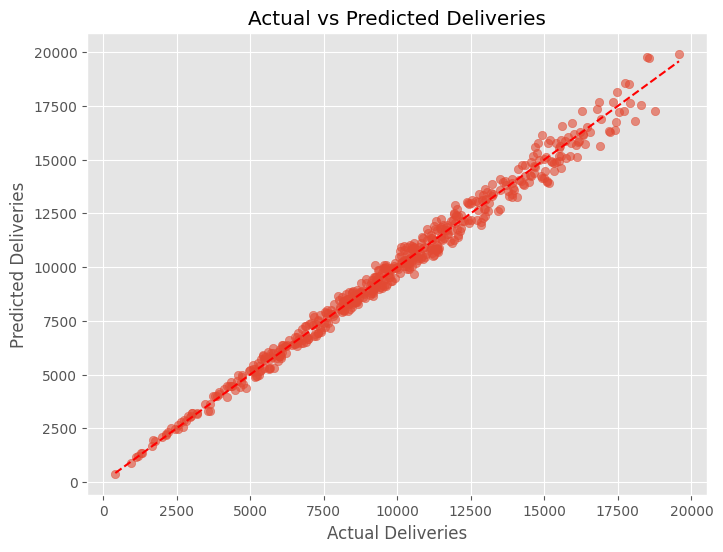

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.show()

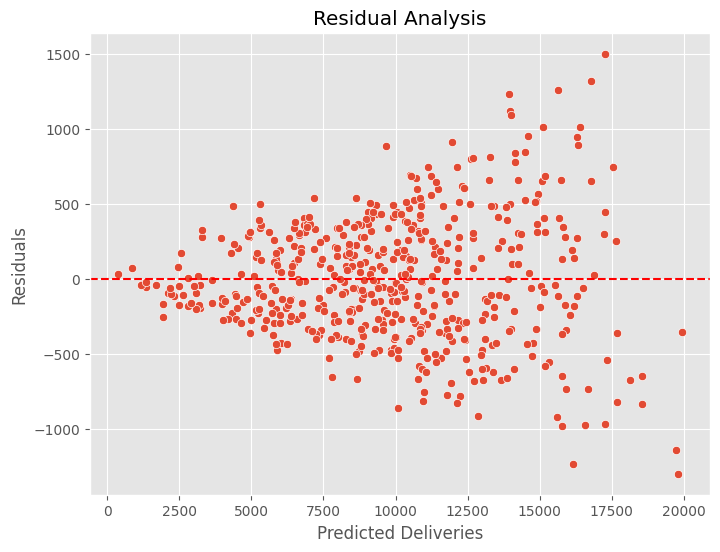

In [42]:
residuals = y_test - best_predictions

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Analysis")
plt.xlabel("Predicted Deliveries")
plt.ylabel("Residuals")

plt.show()

### Observation

The residuals appear randomly distributed around zero, suggesting that the model does not exhibit major systematic prediction errors.

This indicates that the model generalizes well to unseen data.

## Time Series Forecasting

In addition to predicting deliveries using machine learning models, forecasting helps estimate future delivery trends based on historical data.

For forecasting, monthly delivery totals are aggregated and analyzed over time.

In [45]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)

monthly_deliveries = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

monthly_deliveries.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


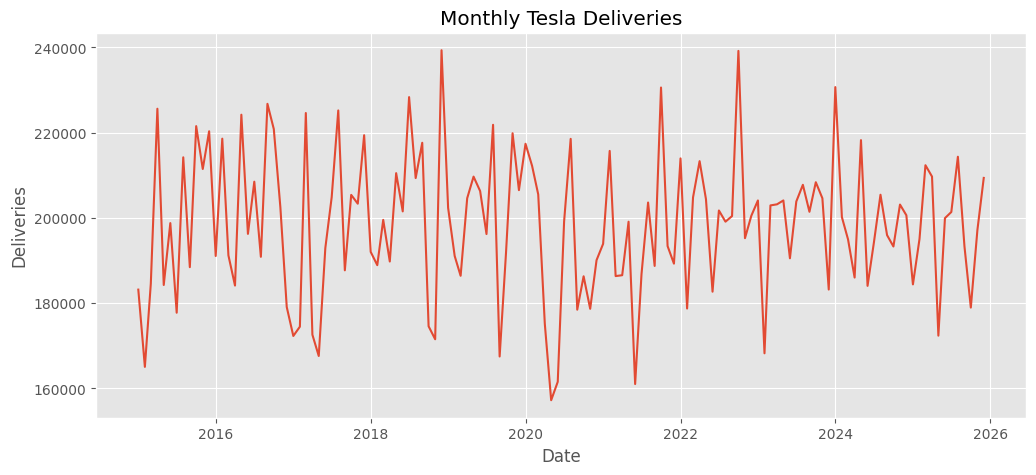

In [46]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_deliveries["Date"],
    monthly_deliveries["Estimated_Deliveries"]
)

plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

### Observation

The monthly delivery trend fluctuates throughout the observed period.

To gain further insight into future delivery behavior, advanced forecasting techniques such as SARIMA and Prophet are applied in the next section.

## Forecasting Future Deliveries

To estimate future Tesla delivery trends, Prophet is used as a time-series forecasting model.

Prophet is developed by Meta and is capable of automatically capturing trends and seasonality in historical data.

The model is trained on monthly delivery records and used to forecast future deliveries for the next 12 months.

Forecasted Deliveries for Next 12 Months


,ds,yhat,yhat_lower,yhat_upper
132,2025-12-31,213529.706260,195003.769186,233906.810013
133,2026-01-31,185169.655353,166176.458158,204101.069162
134,2026-02-28,159843.866784,139774.529685,178689.300765
135,2026-03-31,226314.486069,208132.525475,244371.339724
136,2026-04-30,191242.025246,172424.169611,210842.725392
137,2026-05-31,210386.561699,192198.966773,229127.785125
138,2026-06-30,185025.726840,164344.759411,203318.462905
139,2026-07-31,214030.091480,195291.358429,231895.830365
140,2026-08-31,171945.664530,152941.354791,190094.622423
141,2026-09-30,207346.026096,188576.720838,226265.014965


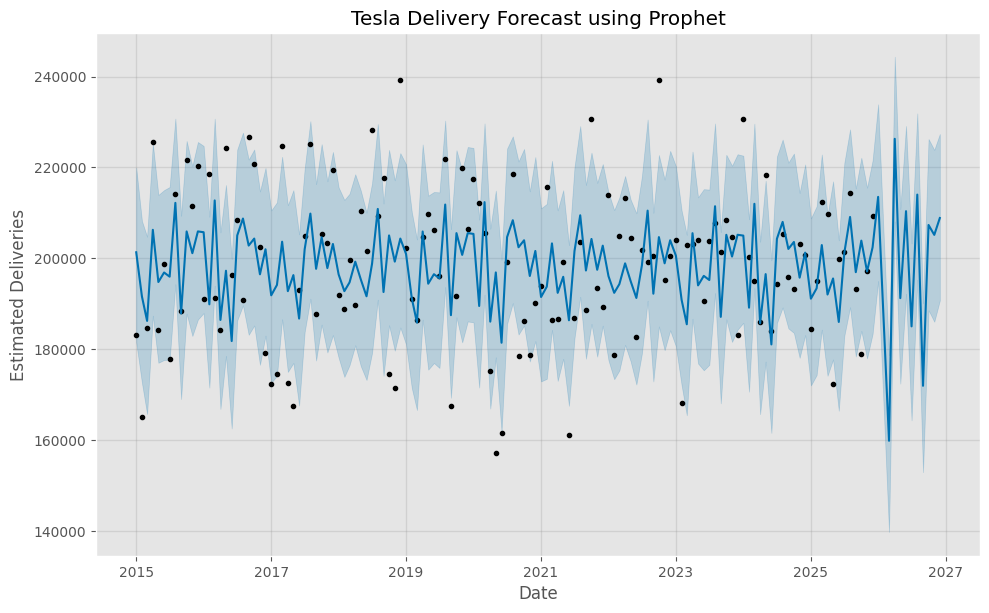

In [50]:
!pip install prophet -q

from prophet import Prophet
prophet_df = monthly_deliveries.rename(
    columns={
        "Date": "ds",
        "Estimated_Deliveries": "y"
    }
)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(
    periods=12,
    freq="M"
)

forecast = prophet_model.predict(future)

print("Forecasted Deliveries for Next 12 Months")
display(
    forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].tail(12)
)

fig = prophet_model.plot(forecast)

plt.title("Tesla Delivery Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

## Forecasting using SARIMA

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting technique that models both trend and seasonality within time-series data.

The SARIMA model is trained using historical monthly delivery observations and used to forecast future delivery volumes.

In [53]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare time series
ts_data = monthly_deliveries.set_index(
    "Date"
)["Estimated_Deliveries"]

# ADF Test
print("ADF Test Results")
adf_result = adfuller(ts_data)

print("ADF Statistic :", round(adf_result[0], 4))
print("p-value       :", round(adf_result[1], 4))

if adf_result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")
sarima_model = SARIMAX(
    ts_data,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_results = sarima_model.fit(
    disp=False
)

print("SARIMA Model Successfully Trained")
sarima_forecast = sarima_results.get_forecast(
    steps=12
)

sarima_predictions = sarima_forecast.predicted_mean

sarima_predictions


ADF Test Results
ADF Statistic : -8.881
p-value       : 0.0
Series is stationary
SARIMA Model Successfully Trained


,predicted_mean
2026-01-01,209863.462905
2026-02-01,204851.343426
2026-03-01,214175.917892
2026-04-01,210741.690087
2026-05-01,203974.550911
2026-06-01,202763.872610
2026-07-01,212260.120412
2026-08-01,221964.724706
2026-09-01,206888.722601
2026-10-01,211178.268650


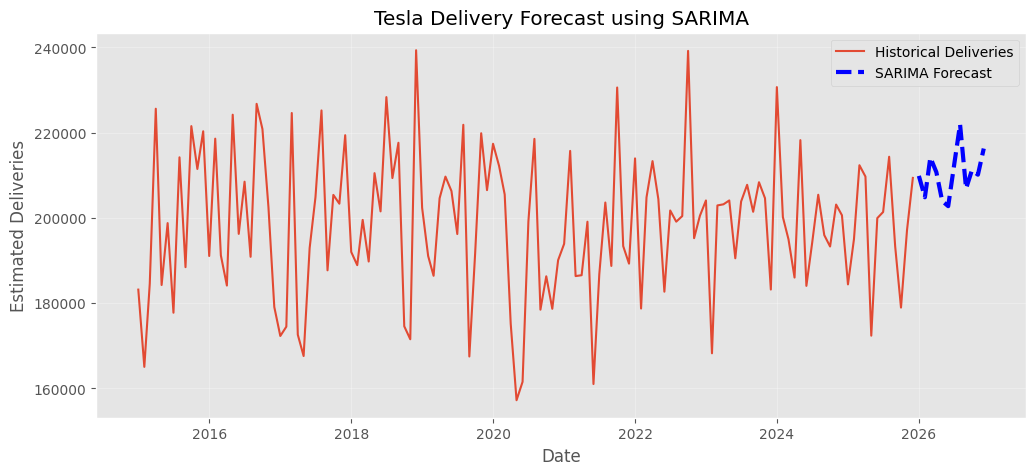

In [56]:
plt.figure(figsize=(12,5))

plt.plot(
    ts_data,
    label="Historical Deliveries"
)

plt.plot(
    sarima_predictions.index,
    sarima_predictions,
    color="blue",
    linewidth=3,
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title("Tesla Delivery Forecast using SARIMA")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Forecasting Observations

The Augmented Dickey-Fuller (ADF) test was performed to evaluate the stationarity of the delivery time series before applying forecasting techniques.

Two forecasting models, Prophet and SARIMA, were used to estimate future Tesla delivery volumes based on historical delivery trends.

The Prophet model captured the overall trend in the data and generated future delivery estimates along with confidence intervals, providing a flexible approach for forecasting.

The SARIMA model leveraged historical patterns and seasonality within the time series to generate future delivery projections.

Both forecasting approaches indicate relatively stable delivery volumes over the forecast horizon, suggesting that future deliveries are expected to remain within a similar range under comparable market and production conditions.

Using multiple forecasting techniques provides a more comprehensive understanding of future delivery behavior and improves confidence in projected trends.

# Conclusion

This project developed an end-to-end machine learning pipeline using Tesla's delivery and production data from 2015 to 2025.

After performing data analysis and feature engineering, Linear Regression and Random Forest models were trained to predict vehicle deliveries. Both models achieved strong performance, with Linear Regression slightly outperforming Random Forest.

Additionally, Prophet and SARIMA models were used for time-series forecasting to estimate future delivery trends.

Overall, the project demonstrates how machine learning and forecasting techniques can be used to analyze business data and support decision-making.